# 沪深300每月定额定投基准收益

本 Notebook 搭建项目统一对照组：**沪深300价格指数（000300）每月定额定投**。

## 固定口径

- 回测区间：2016-01-01 至 2025-12-31（最近 10 个完整自然年度）
- 定投频率：每月一次
- 执行日：每月首个交易日
- 每期投入：1,000 元
- 成交价格：执行日收盘价
- 标的口径：沪深300价格指数，采用虚拟份额核算，不含分红
- 默认交易成本：0（指数不可直接交易；如改用 ETF，请同步修改费率与滑点）

> 重要：定投有持续现金流，因此同时报告三类指标：  
> 1. 账户口径：期末市值、累计投入、累计盈亏、投入收益率；  
> 2. 资金加权口径：XIRR；  
> 3. 时间加权口径：单位净值、年化收益率、最大回撤。  
>
> XIRR 衡量投资者实际投入的资金效率；时间加权净值用于与其他策略公平比较。


## 1. 环境准备

首次运行如缺少 AKShare，请先取消下一行注释并执行：

```python
# %pip install -U akshare
```


In [1]:
from pathlib import Path
from contextlib import contextmanager
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['Heiti SC']
plt.rcParams['axes.unicode_minus'] = False
# 设定全局图像的字体大小
plt.rcParams['font.size'] = 10

## 2. 参数设置

所有团队成员应使用同一组参数；若修改，请在策略说明书中同步披露。


In [2]:
CONFIG = {
    "index_code": "000300",
    "index_name": "沪深300价格指数",
    "start_date": "2016-01-01",
    "end_date": "2025-12-31",
    "monthly_contribution": 1_000.0,
    "buy_timing": "每月首个交易日",
    "execution_price": "close",
    "fee_rate": 0.0,       # 纯指数虚拟基准默认 0；ETF 回测可按实际费率修改
    "min_fee": 0.0,
    "slippage_rate": 0.0,  # 买入成交价 = 收盘价 * (1 + slippage_rate)
    "local_csv": None,     # 例如 "data/csi300_daily.csv"；设定后优先读取本地数据
    "cache_csv": "data/csi300_daily_cache.csv",  # 在线获取成功后自动缓存
    "data_sources": ["tencent", "sina", "eastmoney"],  # 按顺序自动降级
    "retry_times": 2,
    "retry_wait_seconds": 1.5,
    # 仅当报错明确显示“Unable to connect to proxy”且你确认无需系统代理时改为 True
    "ignore_system_proxy": False,
}

CONFIG


{'index_code': '000300',
 'index_name': '沪深300价格指数',
 'start_date': '2016-01-01',
 'end_date': '2025-12-31',
 'monthly_contribution': 1000.0,
 'buy_timing': '每月首个交易日',
 'execution_price': 'close',
 'fee_rate': 0.0,
 'min_fee': 0.0,
 'slippage_rate': 0.0,
 'local_csv': None,
 'cache_csv': 'data/csi300_daily_cache.csv',
 'data_sources': ['tencent', 'sina', 'eastmoney'],
 'retry_times': 2,
 'retry_wait_seconds': 1.5,
 'ignore_system_proxy': False}

## 3. 获取沪深300日行情

本单元格按以下顺序自动获取数据：

1. `CONFIG["local_csv"]` 指定的本地 CSV；
2. 上次成功下载形成的本地缓存；
3. 腾讯财经、 新浪财经、东方财富三个 AKShare 接口（逐个重试并自动降级）。

因此，单个网站临时断开不会直接终止 Notebook。CSV 至少包含日期和收盘价，支持字段名：

- 日期：`date` 或 `日期`
- 收盘价：`close` 或 `收盘`

数据下载后会统一转换为 `date, close` 两列，并执行重复值、缺失值、价格合法性和
区间覆盖检查。若所有在线接口都失败，错误信息会汇总每个数据源的失败原因，并提示
使用本地 CSV。遇到 `Unable to connect to proxy` 且确认当前网络不需要代理时，可将
`CONFIG["ignore_system_proxy"]` 改为 `True` 后重试。


In [3]:
def standardize_price_data(raw: pd.DataFrame) -> pd.DataFrame:
    column_aliases = {
        "日期": "date",
        "date": "date",
        "Date": "date",
        "收盘": "close",
        "close": "close",
        "Close": "close",
    }
    renamed = raw.rename(columns={c: column_aliases.get(c, c) for c in raw.columns})
    required = {"date", "close"}
    missing = required - set(renamed.columns)
    if missing:
        raise ValueError(f"行情缺少必要字段：{sorted(missing)}")

    prices = renamed.loc[:, ["date", "close"]].copy()
    prices["date"] = pd.to_datetime(prices["date"], errors="coerce")
    prices["close"] = pd.to_numeric(prices["close"], errors="coerce")
    prices = (
        prices.dropna(subset=["date", "close"])
        .drop_duplicates(subset="date", keep="last")
        .sort_values("date")
        .set_index("date")
    )
    prices = prices.loc[
        (prices.index >= pd.Timestamp(CONFIG["start_date"]))
        & (prices.index <= pd.Timestamp(CONFIG["end_date"]))
    ]
    if prices.empty:
        raise ValueError("指定区间内没有可用行情。")
    if (prices["close"] <= 0).any():
        raise ValueError("行情中存在非正收盘价，请检查数据。")
    return prices


def validate_price_coverage(prices: pd.DataFrame) -> None:
    start = pd.Timestamp(CONFIG["start_date"])
    end = pd.Timestamp(CONFIG["end_date"])
    # 给节假日和非交易日留出余量，避免接口只返回局部数据却被误用。
    if prices.index.min() > start + pd.Timedelta(days=31):
        raise ValueError(
            f"起始数据覆盖不足：首日为 {prices.index.min().date()}，目标起始日为 {start.date()}"
        )
    if prices.index.max() < end - pd.Timedelta(days=31):
        raise ValueError(
            f"末端数据覆盖不足：末日为 {prices.index.max().date()}，目标结束日为 {end.date()}"
        )


@contextmanager
def temporary_proxy_settings(ignore_system_proxy: bool):
    proxy_keys = [
        "HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY", "NO_PROXY",
        "http_proxy", "https_proxy", "all_proxy", "no_proxy",
    ]
    old_values = {key: os.environ.get(key) for key in proxy_keys}
    try:
        if ignore_system_proxy:
            for key in proxy_keys:
                os.environ.pop(key, None)
            os.environ["NO_PROXY"] = "*"
            os.environ["no_proxy"] = "*"
        yield
    finally:
        for key in proxy_keys:
            if old_values[key] is None:
                os.environ.pop(key, None)
            else:
                os.environ[key] = old_values[key]


def fetch_with_retry(fetcher, source_name: str) -> pd.DataFrame:
    last_error = None
    attempts = max(1, int(CONFIG["retry_times"]))
    for attempt in range(1, attempts + 1):
        try:
            with temporary_proxy_settings(CONFIG["ignore_system_proxy"]):
                raw = fetcher()
            prices = standardize_price_data(raw)
            validate_price_coverage(prices)
            return prices
        except Exception as exc:
            last_error = exc
            print(
                f"  {source_name} 第 {attempt}/{attempts} 次失败："
                f"{type(exc).__name__}: {str(exc)[:180]}"
            )
            if attempt < attempts:
                time.sleep(float(CONFIG["retry_wait_seconds"]))
    raise RuntimeError(f"{source_name} 获取失败") from last_error


def load_csi300_prices() -> tuple[pd.DataFrame, str]:
    local_csv = CONFIG["local_csv"]
    if local_csv:
        prices = standardize_price_data(pd.read_csv(local_csv))
        validate_price_coverage(prices)
        return prices, f"本地 CSV：{local_csv}"

    cache_path = Path(CONFIG["cache_csv"]) if CONFIG["cache_csv"] else None
    if cache_path and cache_path.exists():
        try:
            prices = standardize_price_data(pd.read_csv(cache_path))
            validate_price_coverage(prices)
            return prices, f"本地缓存：{cache_path}"
        except Exception as exc:
            print(f"本地缓存不可用，将尝试在线接口：{type(exc).__name__}: {exc}")

    try:
        import akshare as ak
    except ImportError as exc:
        raise ImportError(
            "未安装 akshare。请先运行 `%pip install -U akshare`，"
            "或在 CONFIG['local_csv'] 中指定本地行情 CSV。"
        ) from exc

    start = pd.Timestamp(CONFIG["start_date"]).strftime("%Y%m%d")
    end = pd.Timestamp(CONFIG["end_date"]).strftime("%Y%m%d")
    providers = {
        "tencent": (
            "AKShare：腾讯财经",
            lambda: ak.stock_zh_index_daily_tx(
                symbol="sh000300", start_date=start, end_date=end
            ),
        ),
        "sina": (
            "AKShare：新浪财经",
            lambda: ak.stock_zh_index_daily(symbol="sh000300"),
        ),
        "eastmoney": (
            "AKShare：东方财富",
            lambda: ak.index_zh_a_hist(
                symbol=CONFIG["index_code"],
                period="daily",
                start_date=start,
                end_date=end,
            ),
        ),
    }

    failures = []
    for provider_key in CONFIG["data_sources"]:
        if provider_key not in providers:
            failures.append(f"{provider_key}: 未知数据源")
            continue
        source_name, fetcher = providers[provider_key]
        print(f"正在尝试 {source_name} ...")
        try:
            prices = fetch_with_retry(fetcher, source_name)
            if cache_path:
                cache_path.parent.mkdir(parents=True, exist_ok=True)
                prices.reset_index().to_csv(cache_path, index=False, encoding="utf-8-sig")
                print(f"已更新本地缓存：{cache_path}")
            return prices, source_name
        except Exception as exc:
            root = exc.__cause__ or exc
            failures.append(
                f"{source_name}: {type(root).__name__}: {str(root)[:220]}"
            )

    details = "\n".join(f"- {item}" for item in failures)
    raise ConnectionError(
        "所有在线行情源均获取失败。\n"
        f"{details}\n\n"
        "可选解决办法：\n"
        "1. 若错误含 Unable to connect to proxy，确认无需代理后将 "
        "CONFIG['ignore_system_proxy'] 设为 True；\n"
        "2. 准备包含 date/close 或 日期/收盘 两列的 CSV，并填写 "
        "CONFIG['local_csv']；\n"
        "3. 稍后重新运行本单元格。"
    )


prices, data_source = load_csi300_prices()
print(f"数据源：{data_source}")
print(f"样本区间：{prices.index.min().date()} 至 {prices.index.max().date()}")
print(f"交易日数量：{len(prices):,}")
display(prices.head())


数据源：本地缓存：data/csi300_daily_cache.csv
样本区间：2016-01-04 至 2025-12-31
交易日数量：2,430


,close
date,
2016-01-04,"3,469.0700"
2016-01-05,"3,478.7800"
2016-01-06,"3,539.8100"
2016-01-07,"3,294.3800"
2016-01-08,"3,361.5600"


## 4. 数据质量检查与定投日生成


In [4]:
quality_report = pd.Series(
    {
        "交易日数量": len(prices),
        "重复日期数量": int(prices.index.duplicated().sum()),
        "收盘价缺失数量": int(prices["close"].isna().sum()),
        "最小收盘价": prices["close"].min(),
        "最大收盘价": prices["close"].max(),
        "首个交易日": prices.index.min().date(),
        "最后交易日": prices.index.max().date(),
    },
    name="检查结果",
)
display(quality_report.to_frame())

# 每月首个可用交易日；自然月无交易数据时不会产生定投记录
monthly_first_dates = (
    prices.reset_index()
    .assign(month=lambda x: x["date"].dt.to_period("M"))
    .groupby("month", as_index=False)
    .first()["date"]
)
scheduled_dates = set(monthly_first_dates)

print(f"计划定投次数：{len(monthly_first_dates)}")
display(pd.DataFrame({"实际定投日": monthly_first_dates}).head(12))


,检查结果
交易日数量,2430
重复日期数量,0
收盘价缺失数量,0
最小收盘价,"2,853.7600"
最大收盘价,"5,807.7200"
首个交易日,2016-01-04
最后交易日,2025-12-31


计划定投次数：120


,实际定投日
0,2016-01-04
1,2016-02-01
2,2016-03-01
3,2016-04-01
4,2016-05-03
5,2016-06-01
6,2016-07-01
7,2016-08-01
8,2016-09-01
9,2016-10-10


## 5. 定投回测

每次现金投入后，扣除手续费并按成交价买入虚拟指数份额：

$$
\text{买入份额}_t =
\frac{\text{投入金额}-\text{手续费}}
{\text{收盘价}_t(1+\text{滑点率})}
$$

每日账户市值等于累计份额乘以当日收盘价。时间加权单位净值以首次定投日为 1，
之后只反映指数本身的涨跌，不受后续现金流影响。


In [5]:
def run_dca_backtest(prices: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    contribution = float(CONFIG["monthly_contribution"])
    total_units = 0.0
    total_contributed = 0.0
    records, trades = [], []

    for dt, row in prices.iterrows():
        close = float(row["close"])
        cashflow = 0.0
        bought_units = 0.0
        fee = 0.0

        if dt in scheduled_dates:
            cashflow = contribution
            fee = max(cashflow * CONFIG["fee_rate"], CONFIG["min_fee"])
            if fee >= cashflow:
                raise ValueError("单次手续费不能大于或等于投入金额。")
            execution_price = close * (1 + CONFIG["slippage_rate"])
            bought_units = (cashflow - fee) / execution_price
            total_units += bought_units
            total_contributed += cashflow
            trades.append(
                {
                    "date": dt,
                    "contribution": cashflow,
                    "close": close,
                    "execution_price": execution_price,
                    "fee": fee,
                    "units_bought": bought_units,
                    "cumulative_units": total_units,
                    "cumulative_contribution": total_contributed,
                }
            )

        market_value = total_units * close
        records.append(
            {
                "date": dt,
                "close": close,
                "cashflow": cashflow,
                "units_bought": bought_units,
                "units": total_units,
                "cumulative_contribution": total_contributed,
                "market_value": market_value,
            }
        )

    daily = pd.DataFrame(records).set_index("date")
    trades = pd.DataFrame(trades).set_index("date")
    daily = daily.loc[daily["cumulative_contribution"] > 0].copy()
    first_investment_close = daily["close"].iloc[0]
    daily["profit"] = daily["market_value"] - daily["cumulative_contribution"]
    daily["investment_return"] = (
        daily["market_value"] / daily["cumulative_contribution"] - 1
    )
    daily["time_weighted_nav"] = daily["close"] / first_investment_close
    daily["running_peak"] = daily["time_weighted_nav"].cummax()
    daily["drawdown"] = daily["time_weighted_nav"] / daily["running_peak"] - 1
    return daily, trades


daily, trades = run_dca_backtest(prices)
display(trades.head())
display(daily.tail())


,contribution,close,execution_price,fee,units_bought,cumulative_units,cumulative_contribution
date,,,,,,,
2016-01-04,"1,000.0000","3,469.0700","3,469.0700",0.0000,0.2883,0.2883,"1,000.0000"
2016-02-01,"1,000.0000","2,901.0500","2,901.0500",0.0000,0.3447,0.6330,"2,000.0000"
2016-03-01,"1,000.0000","2,930.6900","2,930.6900",0.0000,0.3412,0.9742,"3,000.0000"
2016-04-01,"1,000.0000","3,221.8900","3,221.8900",0.0000,0.3104,1.2846,"4,000.0000"
2016-05-03,"1,000.0000","3,213.5400","3,213.5400",0.0000,0.3112,1.5957,"5,000.0000"


,close,cashflow,units_bought,units,cumulative_contribution,market_value,profit,investment_return,time_weighted_nav,running_peak,drawdown
date,,,,,,,,,,,
2025-12-25,"4,642.5400",0.0000,0.0000,31.0399,"120,000.0000","144,104.1369","24,104.1369",0.2009,1.3383,1.6741,-0.2006
2025-12-26,"4,657.2400",0.0000,0.0000,31.0399,"120,000.0000","144,560.4240","24,560.4240",0.2047,1.3425,1.6741,-0.1981
2025-12-29,"4,639.3700",0.0000,0.0000,31.0399,"120,000.0000","144,005.7403","24,005.7403",0.2000,1.3374,1.6741,-0.2012
2025-12-30,"4,651.2800",0.0000,0.0000,31.0399,"120,000.0000","144,375.4259","24,375.4259",0.2031,1.3408,1.6741,-0.1991
2025-12-31,"4,629.9400",0.0000,0.0000,31.0399,"120,000.0000","143,713.0337","23,713.0337",0.1976,1.3346,1.6741,-0.2028


## 6. 绩效指标


In [6]:
def xnpv(rate: float, cashflows: list[tuple[pd.Timestamp, float]]) -> float:
    first_date = cashflows[0][0]
    return sum(
        value / (1 + rate) ** ((date - first_date).days / 365.0)
        for date, value in cashflows
    )


def xirr(cashflows: list[tuple[pd.Timestamp, float]]) -> float:
    # 允许极低收益率，并动态扩展上界；无有效根时返回 NaN
    if not (any(v < 0 for _, v in cashflows) and any(v > 0 for _, v in cashflows)):
        return np.nan
    lower, upper = -0.9999, 1.0
    f_lower, f_upper = xnpv(lower, cashflows), xnpv(upper, cashflows)
    while f_lower * f_upper > 0 and upper < 1_000:
        upper *= 2
        f_upper = xnpv(upper, cashflows)
    if f_lower * f_upper > 0:
        return np.nan
    return brentq(lambda r: xnpv(r, cashflows), lower, upper)


cashflows = [(dt, -float(v)) for dt, v in trades["contribution"].items()]
cashflows.append((daily.index[-1], float(daily["market_value"].iloc[-1])))
money_weighted_return = xirr(cashflows)

elapsed_years = (daily.index[-1] - daily.index[0]).days / 365.25
twr_cagr = daily["time_weighted_nav"].iloc[-1] ** (1 / elapsed_years) - 1
daily_twr_return = daily["time_weighted_nav"].pct_change().dropna()
annualized_volatility = daily_twr_return.std(ddof=1) * np.sqrt(252)
max_drawdown = daily["drawdown"].min()

metrics = pd.Series(
    {
        "回测开始": daily.index[0].date(),
        "回测结束": daily.index[-1].date(),
        "定投次数": len(trades),
        "累计投入（元）": daily["cumulative_contribution"].iloc[-1],
        "期末市值（元）": daily["market_value"].iloc[-1],
        "累计盈亏（元）": daily["profit"].iloc[-1],
        "投入收益率": daily["investment_return"].iloc[-1],
        "XIRR（资金加权年化）": money_weighted_return,
        "时间加权累计收益": daily["time_weighted_nav"].iloc[-1] - 1,
        "时间加权年化收益": twr_cagr,
        "年化波动率": annualized_volatility,
        "最大回撤": max_drawdown,
        "总手续费（元）": trades["fee"].sum(),
    },
    name="基准结果",
)

display(metrics.to_frame())


,基准结果
回测开始,2016-01-04
回测结束,2025-12-31
定投次数,120
累计投入（元）,"120,000.0000"
期末市值（元）,"143,713.0337"
累计盈亏（元）,"23,713.0337"
投入收益率,0.1976
XIRR（资金加权年化）,0.0354
时间加权累计收益,0.3346
时间加权年化收益,0.0293


### 格式化核心结果


In [7]:
result_table = pd.DataFrame(
    {
        "指标": [
            "累计投入",
            "期末市值",
            "累计盈亏",
            "投入收益率",
            "XIRR（资金加权年化）",
            "时间加权年化收益",
            "最大回撤",
            "定投次数",
        ],
        "结果": [
            f'{metrics["累计投入（元）"]:,.2f} 元',
            f'{metrics["期末市值（元）"]:,.2f} 元',
            f'{metrics["累计盈亏（元）"]:,.2f} 元',
            f'{metrics["投入收益率"]:.2%}',
            f'{metrics["XIRR（资金加权年化）"]:.2%}',
            f'{metrics["时间加权年化收益"]:.2%}',
            f'{metrics["最大回撤"]:.2%}',
            f'{int(metrics["定投次数"])} 次',
        ],
    }
)
display(result_table)


,指标,结果
0,累计投入,"120,000.00 元"
1,期末市值,"143,713.03 元"
2,累计盈亏,"23,713.03 元"
3,投入收益率,19.76%
4,XIRR（资金加权年化）,3.54%
5,时间加权年化收益,2.93%
6,最大回撤,-45.60%
7,定投次数,120 次


## 7. 可视化


### 沪深300指数曲线与定投买入点

红色倒三角标记每月实际买入点；为避免文字重叠，仅对首笔、末笔及每年首笔交易标注日期和指数点位。


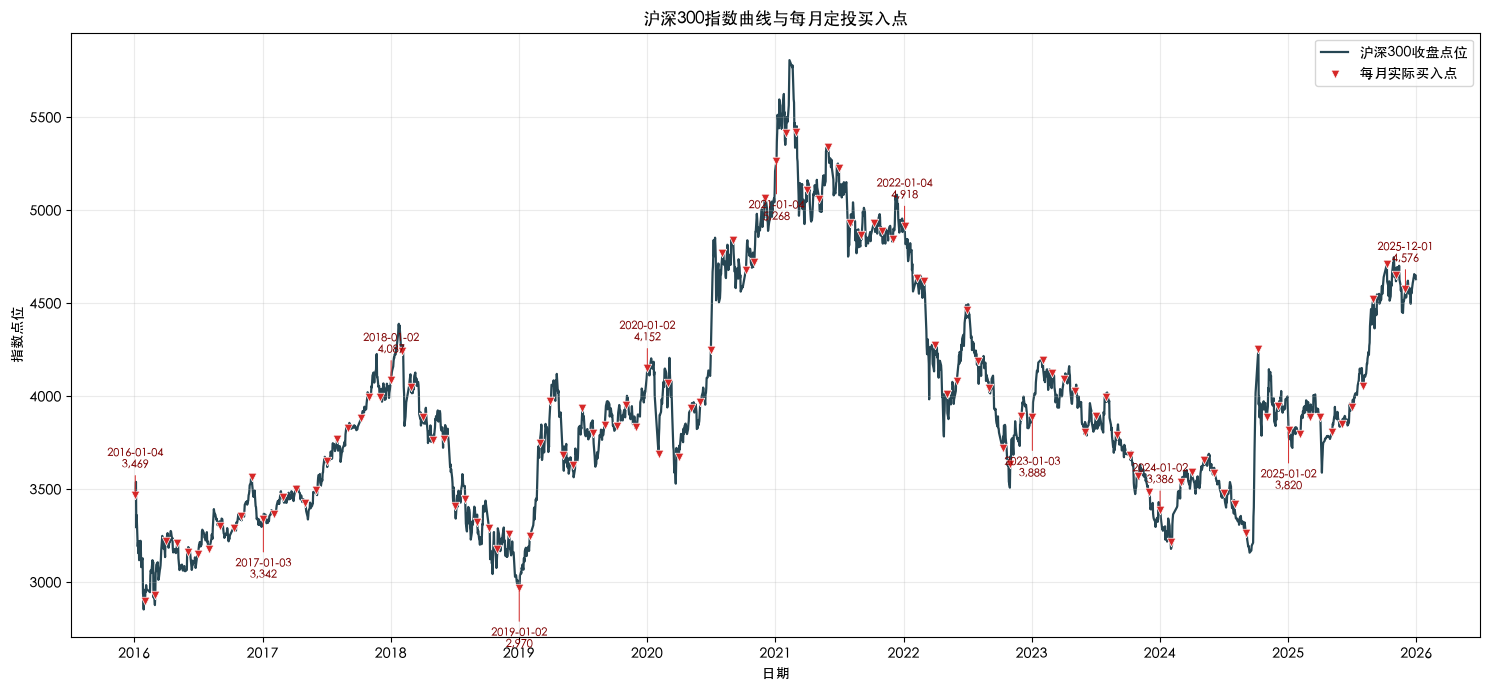

In [8]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    prices.index,
    prices["close"],
    color="#264653",
    linewidth=1.6,
    label="沪深300收盘点位",
    zorder=1,
)
ax.scatter(
    trades.index,
    trades["close"],
    color="#D62828",
    marker="v",
    s=38,
    edgecolors="white",
    linewidths=0.5,
    label="每月实际买入点",
    zorder=3,
)

# 标注首笔、末笔及每年首笔买入，避免 120 个文字标签互相遮挡
annual_first_buys = trades.groupby(trades.index.year).head(1)
label_dates = annual_first_buys.index.union(
    pd.DatetimeIndex([trades.index[0], trades.index[-1]])
).unique().sort_values()

for i, dt in enumerate(label_dates):
    point = trades.loc[dt]
    y_offset = 18 if i % 2 == 0 else -28
    ax.annotate(
        f'{dt:%Y-%m-%d}\n{point["close"]:,.0f}',
        xy=(dt, point["close"]),
        xytext=(0, y_offset),
        textcoords="offset points",
        ha="center",
        va="bottom" if y_offset > 0 else "top",
        fontsize=8,
        color="#7F0000",
        arrowprops={"arrowstyle": "-", "color": "#D62828", "lw": 0.7},
    )

ax.set_title("沪深300指数曲线与每月定投买入点")
ax.set_xlabel("日期")
ax.set_ylabel("指数点位")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


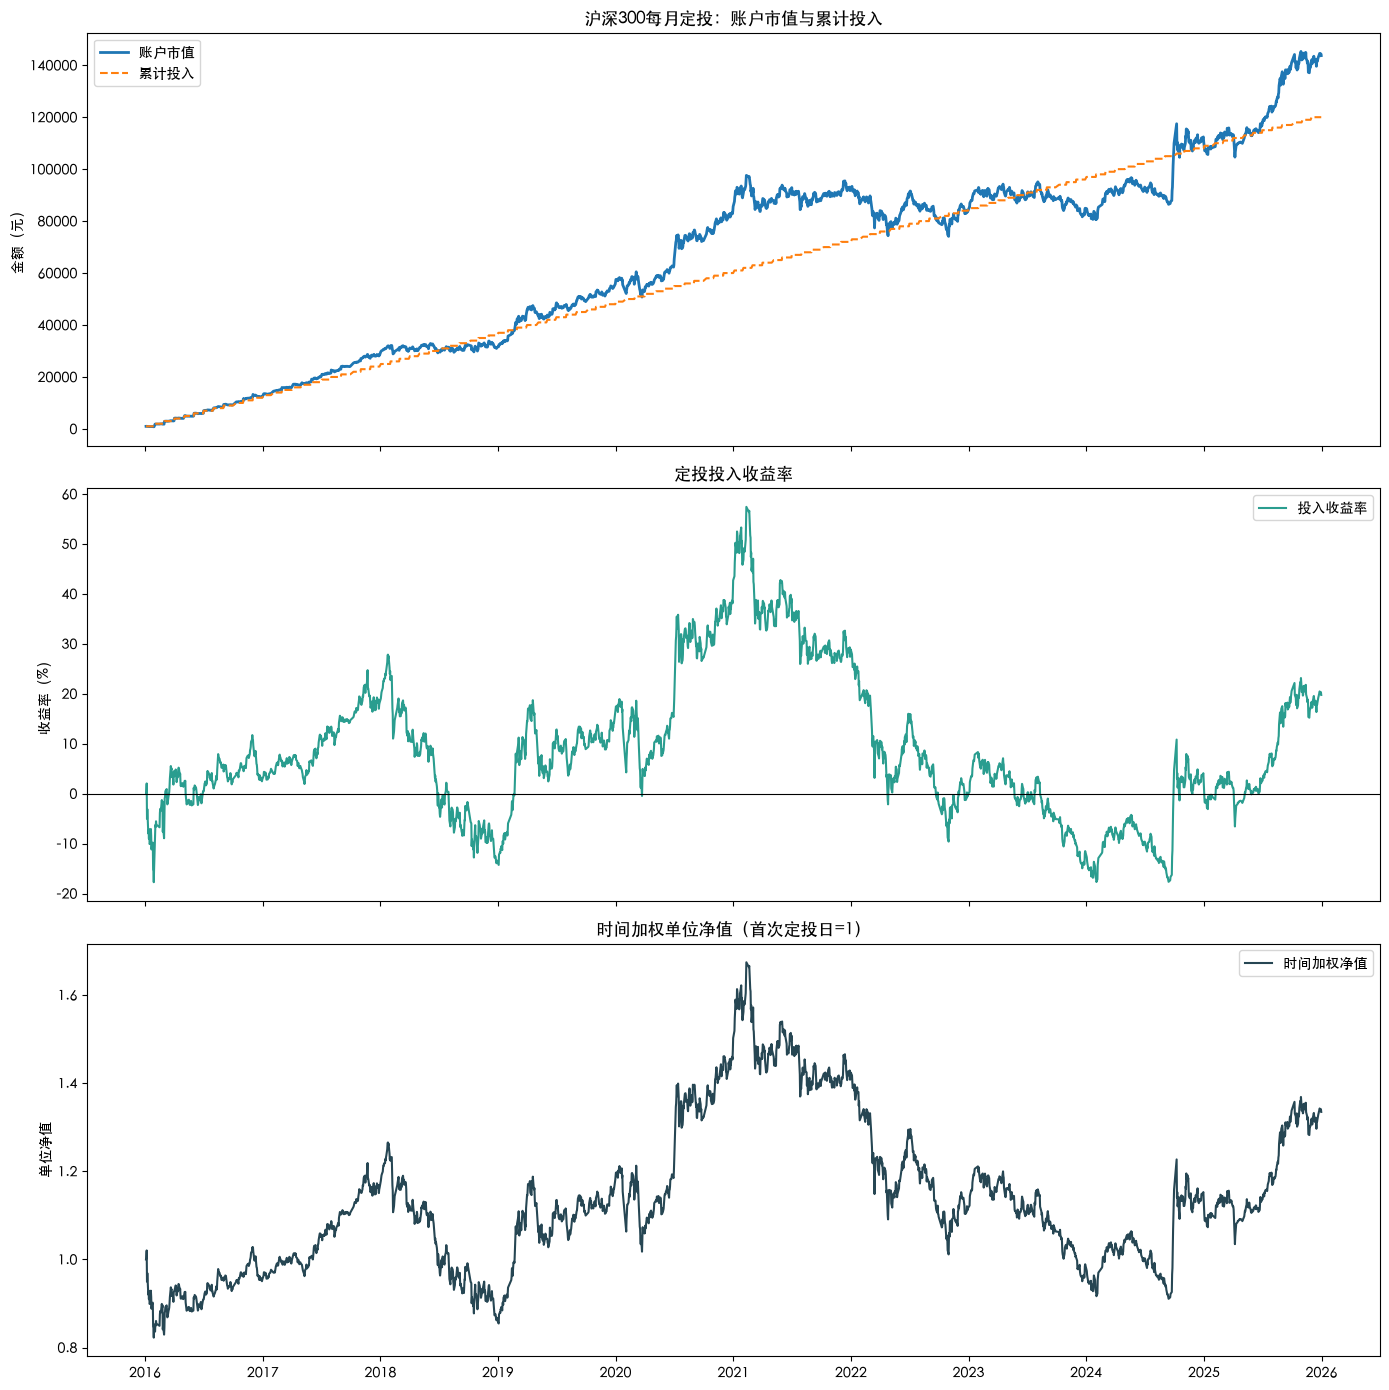

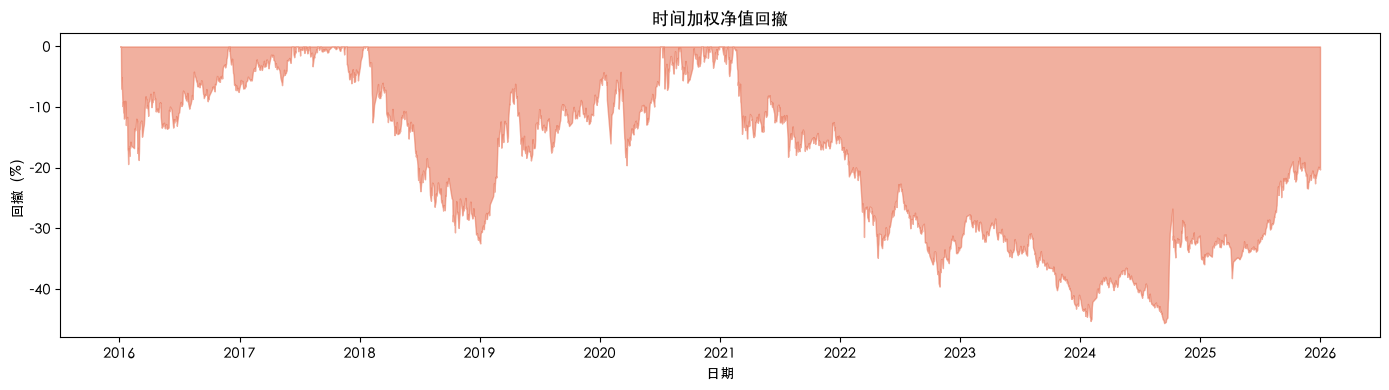

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

axes[0].plot(daily.index, daily["market_value"], label="账户市值", linewidth=2)
axes[0].plot(
    daily.index,
    daily["cumulative_contribution"],
    label="累计投入",
    linewidth=1.5,
    linestyle="--",
)
axes[0].set_title("沪深300每月定投：账户市值与累计投入")
axes[0].set_ylabel("金额（元）")
axes[0].legend()

axes[1].plot(
    daily.index,
    daily["investment_return"] * 100,
    color="#2A9D8F",
    label="投入收益率",
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("定投投入收益率")
axes[1].set_ylabel("收益率（%）")
axes[1].legend()

axes[2].plot(
    daily.index,
    daily["time_weighted_nav"],
    color="#264653",
    label="时间加权净值",
)
axes[2].set_title("时间加权单位净值（首次定投日=1）")
axes[2].set_ylabel("单位净值")
axes[2].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(daily.index, daily["drawdown"] * 100, 0, color="#E76F51", alpha=0.55)
ax.set_title("时间加权净值回撤")
ax.set_ylabel("回撤（%）")
ax.set_xlabel("日期")
plt.tight_layout()
plt.show()


## 8. 分年度结果


In [10]:
year_end = daily.groupby(daily.index.year).tail(1).copy()
year_end["year"] = year_end.index.year
annual_contribution_by_year = trades["contribution"].groupby(trades.index.year).sum()
year_end["annual_contribution"] = year_end["year"].map(annual_contribution_by_year)
year_end["annual_twr_return"] = year_end["time_weighted_nav"].pct_change()
year_end.loc[year_end.index[0], "annual_twr_return"] = (
    year_end["time_weighted_nav"].iloc[0] - 1
)

annual_summary = year_end[
    [
        "year",
        "annual_contribution",
        "cumulative_contribution",
        "market_value",
        "profit",
        "investment_return",
        "annual_twr_return",
    ]
].copy()
annual_summary.columns = [
    "年份",
    "当年投入",
    "累计投入",
    "年末市值",
    "累计盈亏",
    "投入收益率",
    "当年时间加权收益",
]
display(annual_summary.set_index("年份"))


,当年投入,累计投入,年末市值,累计盈亏,投入收益率,当年时间加权收益
年份,,,,,,
2016,"12,000.0000","12,000.0000","12,342.1136",342.1136,0.0285,-0.0458
2017,"12,000.0000","24,000.0000","28,358.9346","4,358.9346",0.1816,0.2178
2018,"12,000.0000","36,000.0000","31,192.1845","-4,807.8155",-0.1336,-0.2531
2019,"12,000.0000","48,000.0000","55,801.4812","7,801.4812",0.1625,0.3607
2020,"12,000.0000","60,000.0000","85,628.9939","25,628.9939",0.4271,0.2721
2021,"12,000.0000","72,000.0000","92,799.3204","20,799.3204",0.2889,-0.0520
2022,"12,000.0000","84,000.0000","83,852.4955",-147.5045,-0.0018,-0.2163
2023,"12,000.0000","96,000.0000","84,956.3368","-11,043.6632",-0.1150,-0.1138
2024,"12,000.0000","108,000.0000","110,614.5463","2,614.5463",0.0242,0.1468


## 9. 结果审计


In [11]:
assert daily.index.is_monotonic_increasing, "日期未按升序排列"
assert not daily.index.duplicated().any(), "存在重复交易日"
assert len(trades) == daily.index.to_period("M").nunique(), "每月定投次数异常"
assert (trades["contribution"] > 0).all(), "存在非正投入"
assert (daily["units"].diff().fillna(daily["units"]) >= -1e-12).all(), "份额不应下降"
assert np.allclose(
    daily["market_value"], daily["units"] * daily["close"]
), "市值核算不一致"
assert daily["drawdown"].between(-1, 1e-12).all(), "回撤范围异常"

print("全部审计检查通过。")


全部审计检查通过。


## 10. 导出回测结果


In [12]:
output_dir = Path("baseline_outputs")
output_dir.mkdir(exist_ok=True)

daily.to_csv(output_dir / "csi300_dca_daily.csv", encoding="utf-8-sig")
trades.to_csv(output_dir / "csi300_dca_trades.csv", encoding="utf-8-sig")
annual_summary.to_csv(
    output_dir / "csi300_dca_annual_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
result_table.to_csv(
    output_dir / "csi300_dca_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

print(f"结果已导出至：{output_dir.resolve()}")


结果已导出至：/Users/chenlang/Main/quant-learning-journey/beat DCA/baseline_outputs


## 11. 结果解读模板

运行 Notebook 后，可按以下结构撰写基准结论：

1. **资金投入**：回测期间共定投若干次，累计投入若干元，期末市值若干元。
2. **投资者体验**：投入收益率反映“当前相对累计本金赚了多少”；XIRR 反映每笔投入时间不同后的真实资金年化效率。
3. **标的表现**：时间加权年化收益与最大回撤反映沪深300本身的收益和风险，可作为量化策略的统一对照口径。
4. **口径限制**：当前使用价格指数，不含分红；指数不可直接交易，实际可投资回测应改用沪深300ETF复权行情，并纳入手续费、滑点、管理费和跟踪误差。
5. **公平比较**：后续策略必须与本基准使用相同起止日期、现金投入节奏、成交时点、成本假设和绩效计算方法。
